# PCA

This notebook performs the PCA over all 2017 ice pixels.


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import time
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
# Loads combined parquet files for all regions, concatenates them, and identifies AE columns.

LOCAL_DIR = Path("C:\\Users\\admin\\OneDrive\\Glacier-Melt-Code\\Parquets_2017")
REGIONS = ['R1a', 'R1b', 'R2', 'R3']

t0 = time.time()
dfs = []
for region in REGIONS:
    df = pd.read_parquet(LOCAL_DIR / f'{region.lower()}_combined.parquet')
    df['region'] = region
    dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
print(f'Loaded {len(df_all):,} pixels in {time.time()-t0:.1f}s')
print(f'Memory: {df_all.memory_usage(deep=True).sum() / 1e9:.2f} GB')

# Identify AE columns
ae_cols = [c for c in df_all.columns 
           if c.startswith('A') and len(c) == 3 and c[1:].isdigit()]
print(f'AlphaEarth bands: {len(ae_cols)} (expected 64)')
assert len(ae_cols) == 64, 'Wrong number of AE bands'

Loaded 15,242,639 pixels in 6.3s
Memory: 4.55 GB
AlphaEarth bands: 64 (expected 64)


In [ ]:
# Fit PCA on AE bands

t0 = time.time()

# Extract AE values as numpy array (more memory-efficient for sklearn)
X_ae = df_all[ae_cols].values.astype(np.float32)
print(f'AE matrix: {X_ae.shape}, {X_ae.nbytes / 1e9:.2f} GB')

# Standardise: zero mean, unit variance per band
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ae)
print(f'Standardised in {time.time()-t0:.1f}s')

# Fit PCA, keep all 64 components
t1 = time.time()
pca = PCA(n_components=64, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA fit + transform in {time.time()-t1:.1f}s')

del X_scaled
import gc; gc.collect()


AE matrix: (15242639, 64), 3.90 GB
Standardised in 15.8s
PCA fit + transform in 4.2s


18

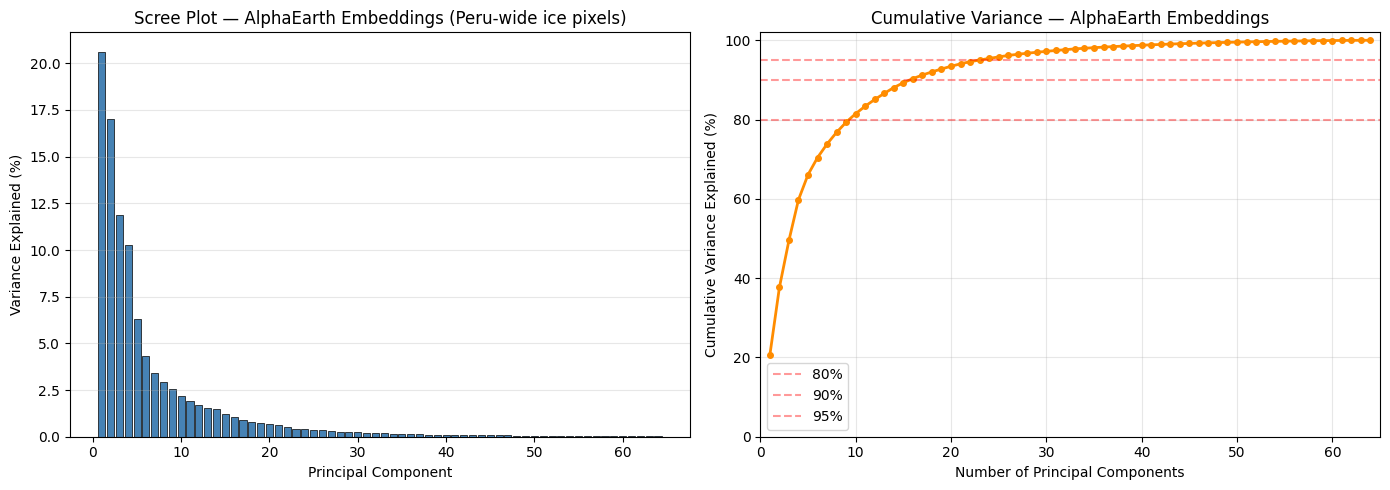

70% variance reached at PC6
80% variance reached at PC10
90% variance reached at PC16
95% variance reached at PC23
99% variance reached at PC43


In [6]:
# Produces scree plot and cumulative variance plot

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 65), pca.explained_variance_ratio_ * 100, 
            color='steelblue', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — AlphaEarth Embeddings (Peru-wide ice pixels)')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, 65), cum_var, color='darkorange', linewidth=2, marker='o', 
             markersize=4)
for threshold, color in [(80, 'red'), (90, 'red'), (95, 'red')]:
    axes[1].axhline(threshold, linestyle='--', color=color, alpha=0.4, 
                    label=f'{threshold}%')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance — AlphaEarth Embeddings')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 65)
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.savefig(LOCAL_DIR / 'pca_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Print which k achieves common variance thresholds
for threshold in [70, 80, 90, 95, 99]:
    k = np.argmax(cum_var >= threshold) + 1
    print(f'{threshold}% variance reached at PC{k}')

In [ ]:
# Quick check: do the top variance PCs also separate melt vs non-melt pixels?

# Mean separation between melt and non-melt classes in each PC
melt_mask = df_all['melt_label'].values == 1
melt_means = X_pca[melt_mask].mean(axis=0)
nonmelt_means = X_pca[~melt_mask].mean(axis=0)
diffs = np.abs(melt_means - nonmelt_means)

# Print all 20 most informative PCs ranked by separation
ranked = np.argsort(diffs)[::-1]
print(f'{"Rank":<5}{"PC":<6}{"|Δmean|":<10}{"VarExp%":<10}')
for rank, idx in enumerate(ranked[:20]):
    print(f'{rank+1:<5}{idx+1:<6}{diffs[idx]:<10.4f}{pca.explained_variance_ratio_[idx]*100:<10.3f}')

# Also: what fraction of total melt-discriminative power is in the top-k variance PCs?
total_diff = diffs.sum()
for k in [3, 6, 10, 15, 20]:
    top_k_idx = np.argsort(pca.explained_variance_ratio_)[::-1][:k]  # top-k by variance
    print(f'Top {k:2d} variance-ranked PCs capture '
          f'{diffs[top_k_idx].sum()/total_diff*100:.1f}% of total melt separation')

Rank PC    |Δmean|   VarExp%   
1    3     3.5717    11.863    
2    1     1.4791    20.627    
3    5     1.3720    6.310     
4    2     0.9786    17.023    
5    4     0.8555    10.263    
6    11    0.3753    1.890     
7    8     0.3457    2.945     
8    16    0.2245    1.045     
9    12    0.1703    1.689     
10   19    0.1634    0.724     
11   6     0.1592    4.328     
12   10    0.1549    2.155     
13   9     0.1294    2.547     
14   17    0.1278    0.895     
15   13    0.1049    1.545     
16   24    0.0919    0.402     
17   20    0.0823    0.693     
18   18    0.0761    0.800     
19   15    0.0705    1.218     
20   14    0.0587    1.461     
Top  3 variance-ranked PCs capture 54.1% of total melt separation
Top  6 variance-ranked PCs capture 75.5% of total melt separation
Top 10 variance-ranked PCs capture 81.7% of total melt separation
Top 15 variance-ranked PCs capture 88.7% of total melt separation
Top 20 variance-ranked PCs capture 94.7% of total melt separatio